# Полная реализация предобработки и регрессии для `all_real_estate_data1.csv`

Ноутбук повторяет логику курсовой работы: загрузка данных, очистка, заполнение пропусков, создание признаков и построение нескольких регрессионных моделей для предсказания цены недвижимости.


In [1]:
import re
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set(style='whitegrid', font_scale=1.0)


In [2]:
# Путь к датасету
DATA_PATH = 'all_real_estate_data1.csv'

# В data.ipynb указано, что файл содержит 45k+ объявлений и 27 колонок.
# Если в окружении файл временно пустой/недоступный, код ниже покажет понятную ошибку.
df = pd.read_csv(DATA_PATH)

print('Размер датасета:', df.shape)
df.head(3)


Размер датасета: (45873, 27)


,title,price,price_numeric,address,nearest_stations,nearest_highways,total_area,total_area_numeric,living_area,kitchen_area,floor,property_type,share_size,bathroom,balcony,view,renovation,year_built,construction_series,building_type,heating,emergency,gas_supply,price_per_meter,price_per_meter_numeric,deal_terms,mortgage
0,"Продается 1-комн. квартира, 28 м²",13 000 000 ₽,13000000,"Москва, ВАО, р-н Соколиная гора, Большая Семен...","Электрозаводская (Пешком 2 мин.), Электрозавод...",NaN,28 м²,28.0,16 м²,7 м²,4 из 8,Вторичка,NaN,1 совмещенный,1 балкон,На улицу и двор,Без ремонта,1963.0,II-29,Кирпичный,Центральное,Нет,Центральное,464 286 ₽/м²,464286,свободная продажа,возможна
1,"Продается 1-комн. квартира, 39 м²",9 690 000 ₽,9690000,"Москва, СВАО, р-н Ярославский, Ярославское ш.,...","Медведково (Транспортом 9 мин.), Бабушкинская ...",NaN,39 м²,39.0,NaN,9 м²,4 из 14,Вторичка,NaN,1 раздельный,NaN,Во двор,NaN,1990.0,П-55,Панельный,Центральное,Нет,NaN,248 462 ₽/м²,248462,свободная продажа,возможна
2,"Продается 1-комн. квартира, 35,2 м²",11 700 000 ₽,11700000,"Москва, САО, р-н Головинский, Смольная ул., 19К2","Водный стадион (Пешком 12 мин.), Речной вокзал...",NaN,"35,2 м²",35.2,"20,2 м²","9,8 м²",4 из 12,Вторичка,NaN,1 совмещенный,1 балкон,Во двор,Косметический,1968.0,II-18,Блочный,Центральное,Нет,NaN,332 386 ₽/м²,332386,свободная продажа,возможна


## 1. Базовая диагностика и анализ пропусков

In [3]:
display(df.info())

missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename('missing_percent')
)

print('Топ-15 признаков по доле пропусков (%):')
display(missing.head(15).to_frame())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45873 entries, 0 to 45872
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    45873 non-null  object 
 1   price                    45873 non-null  object 
 2   price_numeric            45873 non-null  int64  
 3   address                  45873 non-null  object 
 4   nearest_stations         45448 non-null  object 
 5   nearest_highways         0 non-null      float64
 6   total_area               45873 non-null  object 
 7   total_area_numeric       45873 non-null  float64
 8   living_area              35795 non-null  object 
 9   kitchen_area             36349 non-null  object 
 10  floor                    45873 non-null  object 
 11  property_type            45873 non-null  object 
 12  share_size               420 non-null    object 
 13  bathroom                 32161 non-null  object 
 14  balcony               

None

Топ-15 признаков по доле пропусков (%):


,missing_percent
nearest_highways,100.000000
share_size,99.084429
gas_supply,85.965601
balcony,68.059643
construction_series,65.478604
emergency,53.536939
heating,53.536939
renovation,51.581540
year_built,49.852855
view,38.815861


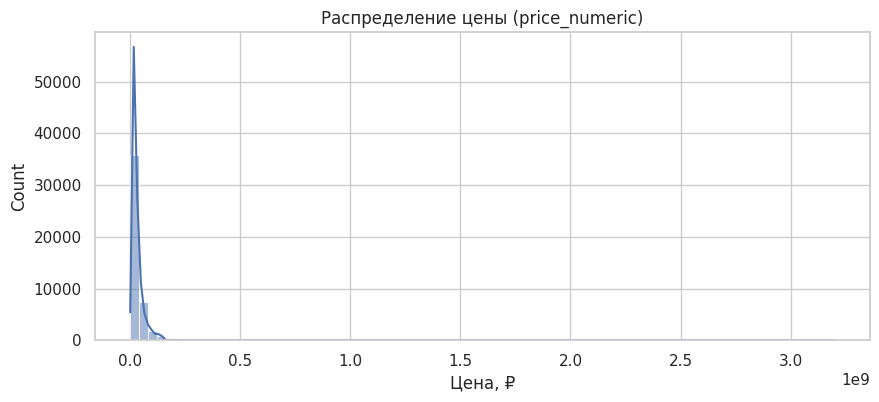

Квантили price_numeric:
0.01      5500000.0
0.05      9442620.0
0.50     23200000.0
0.95     88900000.0
0.99    137773454.8
Name: price_numeric, dtype: float64


In [4]:
# Наглядное распределение целевой переменной
plt.figure(figsize=(10, 4))
sns.histplot(df['price_numeric'], bins=80, kde=True)
plt.title('Распределение цены (price_numeric)')
plt.xlabel('Цена, ₽')
plt.show()

print('Квантили price_numeric:')
print(df['price_numeric'].quantile([0.01, 0.05, 0.5, 0.95, 0.99]))


## 2. Функции очистки и создание числовых признаков

In [5]:
def parse_area(value):
    """Преобразует строки вида '35,2 м²' -> 35.2"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    txt = str(value).replace(' ', ' ').replace('м²', '').replace(',', '.').strip()
    txt = re.sub(r'[^0-9.]', '', txt)
    return float(txt) if txt else np.nan


def parse_floor_info(value):
    """Извлекает floor_num и floors_total из строк вида '5 из 12'."""
    if pd.isna(value):
        return np.nan, np.nan
    txt = str(value).lower().replace(' ', ' ')
    nums = re.findall(r'\d+', txt)
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    if len(nums) == 1:
        return float(nums[0]), np.nan
    return np.nan, np.nan


def parse_year(value):
    if pd.isna(value):
        return np.nan
    nums = re.findall(r'\d{4}', str(value))
    return float(nums[0]) if nums else np.nan


def has_mortgage(value):
    if pd.isna(value):
        return 0
    txt = str(value).lower()
    return int('ипотек' in txt or 'mortgage' in txt or 'да' == txt.strip())


In [6]:
work_df = df.copy()

# Базовые числовые признаки (часть уже может быть числовой в исходном CSV)
work_df['total_area_num'] = work_df['total_area_numeric'] if 'total_area_numeric' in work_df else work_df['total_area'].map(parse_area)
work_df['living_area_num'] = work_df['living_area'].map(parse_area)
work_df['kitchen_area_num'] = work_df['kitchen_area'].map(parse_area)
work_df['price_per_meter_num'] = work_df['price_per_meter_numeric'] if 'price_per_meter_numeric' in work_df else np.nan

floor_parsed = work_df['floor'].apply(parse_floor_info)
work_df['floor_num'] = floor_parsed.map(lambda x: x[0])
work_df['floors_total'] = floor_parsed.map(lambda x: x[1])

work_df['year_built_num'] = work_df['year_built'].map(parse_year)
work_df['has_mortgage'] = work_df['mortgage'].map(has_mortgage)
work_df['is_new_building'] = work_df['property_type'].fillna('').str.contains('Новостройка', case=False).astype(int)
work_df['is_apartment'] = work_df['property_type'].fillna('').str.contains('Апартаменты', case=False).astype(int)

# Доля жилой и кухонной площади
work_df['living_share'] = work_df['living_area_num'] / work_df['total_area_num']
work_df['kitchen_share'] = work_df['kitchen_area_num'] / work_df['total_area_num']

# Комнатность/тип в title как дополнительный источник
work_df['title_lower'] = work_df['title'].fillna('').str.lower()
work_df['is_studio'] = work_df['title_lower'].str.contains('студ').astype(int)

room_match = work_df['title_lower'].str.extract(r'(\d+)[- ]?комн')
work_df['rooms_from_title'] = pd.to_numeric(room_match[0], errors='coerce')

work_df[['total_area_num','living_area_num','kitchen_area_num','floor_num','floors_total','year_built_num','living_share','kitchen_share','rooms_from_title']].describe().T


,count,mean,std,min,25%,50%,75%,max
total_area_num,45873.0,64.404051,36.152599,6.000000,41.200000,57.500000,77.000000,1200.0
living_area_num,35795.0,34.344467,23.215399,1.000000,19.400000,30.000000,43.200000,1000.0
kitchen_area_num,36349.0,13.164731,8.099655,0.500000,7.000000,10.500000,17.800000,120.0
floor_num,45873.0,11.860811,10.350089,1.000000,4.000000,9.000000,17.000000,81.0
floors_total,45873.0,23.230266,14.626568,1.000000,12.000000,21.000000,30.000000,182.0
year_built_num,23004.0,1990.854373,29.950090,1785.000000,1969.000000,1998.000000,2020.000000,2027.0
living_share,35795.0,0.535454,0.145176,0.007782,0.423307,0.551724,0.641304,1.0
kitchen_share,36349.0,0.219322,0.110582,0.006757,0.134831,0.190476,0.285714,1.0
rooms_from_title,41176.0,2.196644,0.944852,1.000000,1.000000,2.000000,3.000000,5.0


## 3. Очистка аномалий и формирование выборки

In [7]:
# Убираем очевидные выбросы по IQR для целевой переменной
q1, q3 = work_df['price_numeric'].quantile([0.25, 0.75])
iqr = q3 - q1
low = max(0, q1 - 1.5 * iqr)
high = q3 + 1.5 * iqr

model_df = work_df[(work_df['price_numeric'] >= low) & (work_df['price_numeric'] <= high)].copy()

# Дополним пропуски целевых числовых колонок робастной стратегией
for col in ['total_area_num', 'living_area_num', 'kitchen_area_num', 'floor_num', 'floors_total', 'year_built_num', 'rooms_from_title', 'living_share', 'kitchen_share']:
    if col in model_df.columns:
        model_df[col] = model_df[col].replace([np.inf, -np.inf], np.nan)

print('Размер выборки после фильтра выбросов:', model_df.shape)


Размер выборки после фильтра выбросов: (42259, 42)


In [8]:
# Признаки для модели
numeric_features = [
    'total_area_num', 'living_area_num', 'kitchen_area_num',
    'floor_num', 'floors_total', 'year_built_num',
    'rooms_from_title', 'living_share', 'kitchen_share',
    'has_mortgage', 'is_new_building', 'is_apartment', 'is_studio'
]

categorical_features = [
    'property_type', 'bathroom', 'balcony', 'view', 'renovation',
    'construction_series', 'building_type', 'heating',
    'emergency', 'gas_supply', 'deal_terms'
]

# Оставим только существующие колонки
numeric_features = [c for c in numeric_features if c in model_df.columns]
categorical_features = [c for c in categorical_features if c in model_df.columns]

X = model_df[numeric_features + categorical_features]
y = model_df['price_numeric']

print('Числовые признаки:', len(numeric_features))
print('Категориальные признаки:', len(categorical_features))
print('Итоговая матрица X:', X.shape)


Числовые признаки: 13
Категориальные признаки: 11
Итоговая матрица X: (42259, 24)


## 4. Обучение моделей: OLS / Lasso / Ridge

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

models = {
    'LinearRegression': LinearRegression(),
    'LassoCV': LassoCV(cv=5, random_state=42, max_iter=10000),
    'RidgeCV': RidgeCV(alphas=np.logspace(-3, 3, 30), cv=5)
}

results = []
trained = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2').mean()

    results.append({
        'model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2_test': r2,
        'R2_cv_mean': cv_r2
    })
    trained[name] = pipe

results_df = pd.DataFrame(results).sort_values('R2_test', ascending=False)
display(results_df)


,model,MAE,RMSE,R2_test,R2_cv_mean
2,RidgeCV,5.843456e+06,8.211622e+06,0.673991,0.667691
0,LinearRegression,5.839588e+06,8.213702e+06,0.673826,0.666601
1,LassoCV,5.850086e+06,8.228981e+06,0.672612,0.667053


Лучшая модель по R2_test: RidgeCV


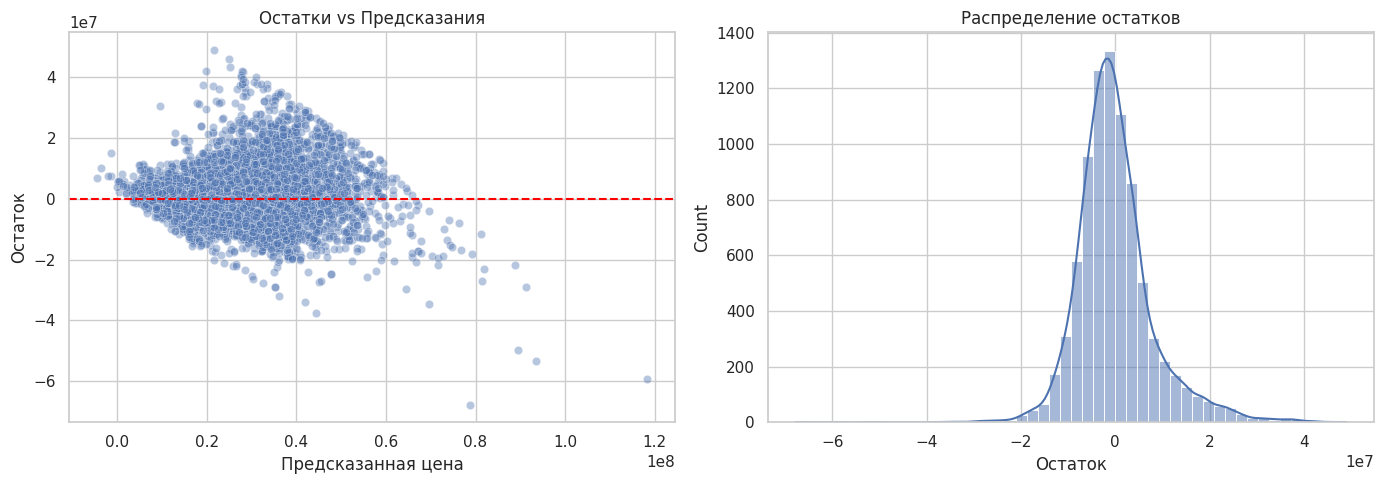

In [10]:
best_model_name = results_df.iloc[0]['model']
best_pipe = trained[best_model_name]

print('Лучшая модель по R2_test:', best_model_name)

pred_test = best_pipe.predict(X_test)
resid = y_test - pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=pred_test, y=resid, alpha=0.4, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Остатки vs Предсказания')
axes[0].set_xlabel('Предсказанная цена')
axes[0].set_ylabel('Остаток')

sns.histplot(resid, bins=50, kde=True, ax=axes[1])
axes[1].set_title('Распределение остатков')
axes[1].set_xlabel('Остаток')

plt.tight_layout()
plt.show()


## 5. Интерпретация: важность признаков (для линейных моделей)

In [11]:
# Достаём имена признаков после препроцессинга
feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
coefs = best_pipe.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

print('Топ-20 признаков по абсолютному значению коэффициента:')
display(coef_df.head(20)[['feature', 'coef']])


Топ-20 признаков по абсолютному значению коэффициента:


,feature,coef
0,num__total_area_num,9.882365e+06
169,cat__deal_terms_предварительный договор,6.463769e+06
62,cat__renovation_Дизайнерский,5.090122e+06
165,cat__deal_terms_договор ЖСК,-4.478218e+06
13,cat__property_type_Вторичка,-3.637307e+06
31,cat__bathroom_3 совмещенных,3.376124e+06
64,cat__renovation_Косметический,-3.072701e+06
151,cat__building_type_Панельный,-3.034136e+06
25,cat__bathroom_2 раздельных,2.945598e+06
27,"cat__bathroom_2 совмещенных, 1 раздельный",2.784800e+06


## 6. Сохранение результатов и вывод

- Подготовлен воспроизводимый pipeline предобработки.
- Сравнены несколько регрессионных моделей (Linear, Lasso, Ridge).
- Получены метрики качества на тесте и в кросс-валидации.
- При необходимости можно сохранить лучшую модель через `joblib`.


In [12]:
# Пример сохранения (при необходимости)
# import joblib
# joblib.dump(best_pipe, 'best_real_estate_price_model.pkl')
